In [2]:
import pandas as pd

df = pd.read_csv("/Users/julia/Documents/spotify_millsongdata.csv")

if "text" in df.columns:
    # Sprawdź, ile utworów ma brakujące teksty
    missing_lyrics = df["text"].isna().sum()
    total_songs = len(df)

    print(f"Liczba utworów w datasetcie: {total_songs}")
    print(f"Liczba utworów bez tekstu: {missing_lyrics}")
    print(f"Procent utworów bez tekstu: {missing_lyrics / total_songs * 100:.2f}%")
else:
    print("Brak kolumny 'text' – dataset nie zawiera tekstów piosenek.")

Liczba utworów w datasetcie: 57650
Liczba utworów bez tekstu: 0
Procent utworów bez tekstu: 0.00%


In [5]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('averaged_perceptron_tagger')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Funkcja do mapowania POS na format WordNet
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()  # Pobranie pierwszej litery tagu POS
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)  # Jeśli brak w słowniku, przyjmujemy rzeczownik

def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Usunięcie liczb
    text = re.sub(r'\W+', ' ', text)  # Usunięcie znaków specjalnych
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]  # Usunięcie stop words
    words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]  # Poprawna lematyzacja
    return ' '.join(words)

df['processed_text'] = df['text'].apply(preprocess_text)


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/julia/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['processed_text'])

# Sprawdzenie wymiarów macierzy
print(X.shape)  # (liczba_piosenek, liczba_słów)


(57650, 5000)


In [7]:
from sklearn.decomposition import LatentDirichletAllocation

# Ustawienie liczby tematów
num_topics = 8

lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)

# Pobranie słów kluczowych dla każdego tematu
def display_topics(model, feature_names, num_words):
    for topic_idx, topic in enumerate(model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
        print(f"Temat {topic_idx+1}: {', '.join(words)}")


# Wyświetlenie tematów
display_topics(lda, vectorizer.get_feature_names_out(), 10)


Temat 1: come, rock, home, roll, good, little, old, new, town, man
Temat 2: oh, love, know, say, time, want, need, way, make, feel
Temat 3: love, like, come, feel, dance, tonight, night, blue, make, light
Temat 4: life, let, world, heart, day, god, dream, love, come, know
Temat 5: na, gon, baby, know, wan, want, let, make, cause, ta
Temat 6: la, away, come, time, like, eye, know, turn, fall, life
Temat 7: like, yeah, ya, nigga, fuck, know, em, shit, cause, money
Temat 8: like, girl, say, hey, man, boy, little, look, make, big


In [ ]:
%pip install transformers
%pip install torch

In [9]:
from transformers import pipeline

# 1. Pipeline do klasyfikacji Zero-Shot
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# 2. Kandydaci na etykiety tematów
candidate_labels = [
    "love", "heartbreak", "party", "freedom", "sadness",
    "happiness", "rebellion", "nostalgia", "hope", "anger"
]

# 3. Funkcja przypisująca etykiety
def get_topic_labels(lda_model, feature_names, num_words=10):
    topic_labels = []

    for topic_idx, topic in enumerate(lda_model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
        topic_keywords = " ".join(words)

        result = classifier(topic_keywords, candidate_labels)
        label = result["labels"][0]  # Najbardziej prawdopodobna etykieta
        topic_labels.append((f"Topic {topic_idx+1}", label, words))

    return topic_labels

# 4. Wywołanie
labels = get_topic_labels(lda, vectorizer.get_feature_names_out())

# 5. Wyświetlenie
for topic_name, label, words in labels:
    print(f"{topic_name} -> {label.upper()} | Keywords: {', '.join(words)}")


Device set to use cpu


Topic 1 -> NOSTALGIA | Keywords: come, rock, home, roll, good, little, old, new, town, man
Topic 2 -> LOVE | Keywords: oh, love, know, say, time, want, need, way, make, feel
Topic 3 -> LOVE | Keywords: love, like, come, feel, dance, tonight, night, blue, make, light
Topic 4 -> HOPE | Keywords: life, let, world, heart, day, god, dream, love, come, know
Topic 5 -> HOPE | Keywords: na, gon, baby, know, wan, want, let, make, cause, ta
Topic 6 -> HEARTBREAK | Keywords: la, away, come, time, like, eye, know, turn, fall, life
Topic 7 -> ANGER | Keywords: like, yeah, ya, nigga, fuck, know, em, shit, cause, money
Topic 8 -> HOPE | Keywords: like, girl, say, hey, man, boy, little, look, make, big


In [11]:
from transformers import pipeline
import torch

# Sprawdzenie, czy dostępny GPU
device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'cuda' if device == 0 else 'cpu'}")

# Ładujemy pipeline do analizy sentymentu
sentiment_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=device)

def classify_sentiment(text):
    if not text or text.strip() == "":
        return "neutral"  # domyślna wartość, jeśli tekst jest pusty
    try:
        result = sentiment_pipeline(text[:512])[0]  # ograniczenie do 512 tokenów
        label = result['label']
        # Mapowanie na uproszczone etykiety
        if '1' in label or '2' in label:
            return 'negative'
        elif '3' in label:
            return 'neutral'
        else:
            return 'positive'
    except Exception as e:
        print(f"Błąd dla tekstu: {text[:30]}... – {e}")
        return 'neutral'
df['sentiment'] = df['processed_text'].apply(classify_sentiment)
df[['processed_text', 'sentiment']].head()


Device: cpu


Device set to use cpu


KeyboardInterrupt: 

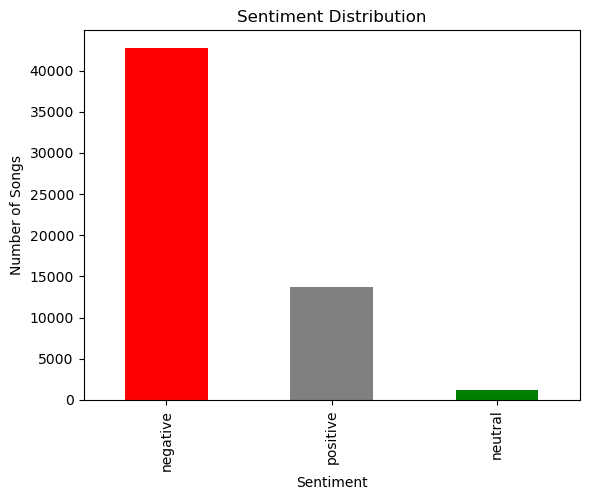

In [ ]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution', color=['red', 'gray', 'green'])
plt.xlabel('Sentiment')
plt.ylabel('Number of Songs')
plt.show()


In [ ]:
%pip install transformers sentencepiece

In [13]:
from transformers import pipeline
import random

# Załaduj model summarizera (działa na CPU)
summarizer = pipeline("summarization", model="Falconsai/text_summarization")

def summarize_random_lyric(df):
    # Wybierz losowy wiersz, który ma tekst po przetwarzaniu
    row = df.dropna(subset=['text']).sample(1).iloc[0]
    original_text = row['text']
    
    # Przetnij tekst, jeśli jest za długi
    if len(original_text) > 1024:
        original_text = original_text[:1024]
    
    # Generowanie streszczenia
    summary = summarizer(original_text, max_length=100, min_length=30, do_sample=False)[0]['summary_text']

    print("🎵 Oryginalny tekst (fragment):\n")
    print(original_text[:500])  # tylko fragment

    print("\n📝 Streszczenie:\n")
    print(summary)

# Użycie funkcji
summarize_random_lyric(df)


Device set to use cpu
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🎵 Oryginalny tekst (fragment):

I have a private hell  
Of excellent quality  
I've dwelt there for years  
Playing with my fears  
  
It's tastefull, luxurious,  
And full of sexuality  
And though they are tears  
I control them with my gears  
  
Well all in all,  
I must tell you,  
Well I must tell you,  
I'm so proud of my private hell  
  
Anger and greed brew  
And then they stamped  
Till I can transmute  
Them into more loot  
  
It's tasteful, luxurious,  
And full of sexuality  
And though the

📝 Streszczenie:

I have a private hell Of excellent quality I've dwelt there for years Playing with my fears It's tastefull, luxurious, And full of sexuality And though they are tears I control them with my gears Well all in all . Well I must tell you, Well I'm so proud of my private hell Anger and greed brew And then they stamped Till I can transmute Them into more loot I'll tell you .
